# 16. Пропуски: три механизма и четыре способа обработки

| | |
|---|---|
| **Уровень** | 3 из 4 — средние данные: полный цикл и типовые случаи (`3_medium`) |
| **Скрипт-источник** | [`16_missing_values.py`](../16_missing_values.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 5 с |

**Цель.** Научиться выбирать обработку пропусков в зависимости от того, почему данные пропали.

### Чему вы научитесь

- Три механизма пропусков: MCAR (случайно), MAR (зависит от другого признака), MNAR (зависит от самого значения)
- Встроенная обработка NaN в XGBoost
- Заполнение медианой
- Медиана + индикатор пропуска
- Удаление признака

### Данные

Задача Фридмана, 20 000 объектов, 10 признаков; пропадает 30% значений сильного признака x3.

### План

1. **Этап 1.** Данные без пропусков
2. **Этап 2.** Три механизма: 30% значений x3 пропадают
3. **Этап 3.** Способы обработки: одна и та же модель XGBoost с ранней остановкой
4. **Этап 5.** Выводы

> Ноутбук собран из `examples/3_medium/16_missing_values.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example

ex = Example(EXAMPLES / "3_medium/16_missing_values.py", title="16. Пропуски: механизмы и способы обработки",
             goal="понять, когда пропуск — информация, и как её не потерять")

import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from gbcourse import datasets
from gbcourse.style import ROLE

## Этап 1. Данные без пропусков

In [2]:
n = ex.size(20_000, 5000)
X, y = datasets.friedman1(n=n, noise=1.0, seed=16)
ex.describe(X, y, names=[f"x{j}" for j in range(10)], target="y", source="gbcourse.datasets.friedman1: y содержит слагаемое 10·x3")
perm = np.random.default_rng(0).permutation(n)
tr, va, te = perm[: int(0.6 * n)], perm[int(0.6 * n): int(0.8 * n)], perm[int(0.8 * n):]

   Источник: gbcourse.datasets.friedman1: y содержит слагаемое 10·x3
   Объектов: 20 000   признаков: 10   память: 1.53 МБ
   Типы признаков: float64 × 10
   Пропусков нет
   Цель «y»: среднее 14.367, σ 4.978, мин -0.291, макс 29.569
   Первые строки:


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,[y]
0,0.631395,0.144322,0.752338,0.388273,0.339685,0.019686,0.937942,0.513364,0.187615,0.933528,10.778970
1,0.273216,0.417759,0.579247,0.846221,0.340868,0.415750,0.848463,0.161629,0.700929,0.318489,13.880645
2,0.480828,0.501491,0.811133,0.797594,0.165463,0.023680,0.868635,0.143713,0.912929,0.618502,16.023123


## Этап 2. Три механизма: 30% значений x3 пропадают

In [3]:
r = np.random.default_rng(1)
mech = {
    "MCAR — случайно": r.random(n) < 0.3,
    "MAR — чаще при большом x0": r.random(n) < 0.6 * X[:, 0],
    "MNAR — чаще при большом x3": r.random(n) < 0.6 * X[:, 3],
}
for name, miss in mech.items():
    print(f"   {name:28s} пропусков {miss.mean():.1%}; средний x3 у пропавших {X[miss, 3].mean():.2f} (у всех {X[:, 3].mean():.2f})")
ex.note("При MNAR сам факт пропуска говорит о значении: пропадают в основном большие x3.")

   MCAR — случайно              пропусков 30.3%; средний x3 у пропавших 0.50 (у всех 0.50)
   MAR — чаще при большом x0    пропусков 30.0%; средний x3 у пропавших 0.50 (у всех 0.50)
   MNAR — чаще при большом x3   пропусков 29.9%; средний x3 у пропавших 0.67 (у всех 0.50)


> ▸ **Вывод.** При MNAR сам факт пропуска говорит о значении: пропадают в основном большие x3.

In [4]:
def fit_rmse(Xa):
    m = xgb.XGBRegressor(n_estimators=3000, learning_rate=0.05, max_depth=5, early_stopping_rounds=100)
    m.fit(Xa[tr], y[tr], eval_set=[(Xa[va], y[va])], verbose=False)
    return float(np.sqrt(np.mean((y[te] - m.predict(Xa[te])) ** 2)))


full = fit_rmse(X)

## Этап 3. Способы обработки: одна и та же модель XGBoost с ранней остановкой

   ориентир — модель без пропусков: RMSE = 1.088
   механизм                      NaN как есть   медиана  медиана+флаг  удалить x3


   MCAR — случайно                     1.969        1.960        1.965        3.085


   MAR — чаще при большом x0           1.977        1.976        1.974        3.085


   MNAR — чаще при большом x3          1.701        1.699        1.705        3.085


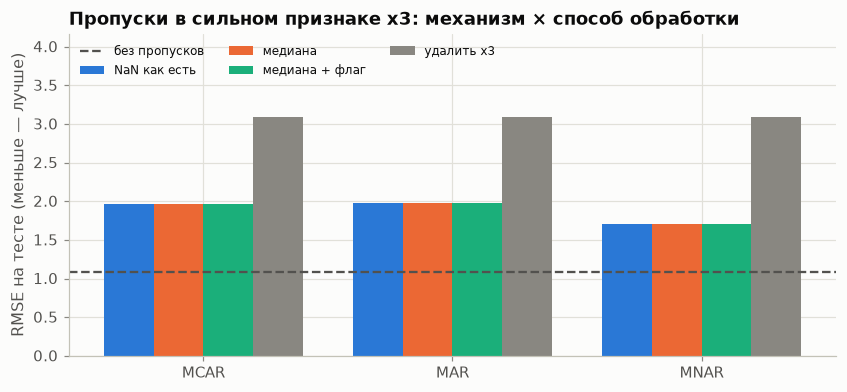

In [5]:
print(f"   ориентир — модель без пропусков: RMSE = {full:.3f}")
print(f"   {'механизм':28s} {'NaN как есть':>13s} {'медиана':>9s} {'медиана+флаг':>13s} {'удалить x3':>11s}")
table = {}
for name, miss in mech.items():
    Xm = X.copy()
    Xm[miss, 3] = np.nan
    med = np.nanmedian(Xm[tr, 3])
    Xmed = Xm.copy()
    Xmed[miss, 3] = med
    Xflag = np.c_[Xmed, miss.astype(float)]
    row = [fit_rmse(Xm), fit_rmse(Xmed), fit_rmse(Xflag), fit_rmse(np.delete(X, 3, 1))]
    table[name] = row
    print(f"   {name:28s} " + " ".join(f"{v:12.3f}" for v in row))

fig, ax = plt.subplots(figsize=(9, 3.8))
methods = ["NaN как есть", "медиана", "медиана + флаг", "удалить x3"]
colors = [ROLE["model"], ROLE["tree"], ROLE["test"], ROLE["truth"]]
for j, (meth, c) in enumerate(zip(methods, colors)):
    ax.bar(np.arange(len(table)) + (j - 1.5) * 0.2, [row[j] for row in table.values()], width=0.2, color=c, label=meth)
ax.axhline(full, color=ROLE["data"], ls="--", lw=1.5, label="без пропусков")
ax.set_xticks(range(len(table)), [k.split(" — ")[0] for k in table])
ax.set(ylabel="RMSE на тесте (меньше — лучше)", title="Пропуски в сильном признаке x3: механизм × способ обработки")
ax.set_ylim(0, max(max(r) for r in table.values()) * 1.35)
ax.legend(ncol=3, fontsize=8, loc="upper left")
ex.finish(fig, "16_missing")

## Этап 5. Выводы

In [6]:
mnar = table["MNAR — чаще при большом x3"]
ex.note(f"""Удалить признак из-за пропусков — худшее решение: он слишком важен ({table['MCAR — случайно'][3]:.3f} против {table['MCAR — случайно'][0]:.3f}).
При MNAR ошибка меньше, чем при MCAR: пропуск сам подсказывает значение (NaN как есть: {mnar[0]:.3f}).
Встроенная обработка NaN и «медиана + флаг» сохраняют факт пропуска и обычно не хуже простого заполнения.""")
assert all(row[3] > row[0] for row in table.values())
ex.done()

> ▸ **Вывод.** Удалить признак из-за пропусков — худшее решение: он слишком важен (3.085 против 1.969). При MNAR ошибка меньше, чем при MCAR: пропуск сам подсказывает значение (NaN как есть: 1.701). Встроенная обработка NaN и «медиана + флаг» сохраняют факт пропуска и обычно не хуже простого заполнения.

Готово за 3.7 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Поднимите долю пропусков до 60% — как меняется таблица?
2. Сделайте MNAR сильнее (вероятность пропуска 0.9·x3) — насколько упадёт ошибка «NaN как есть»?
3. Замените медиану заполнением по соседям (`sklearn.impute.KNNImputer`) и сравните.

## Что дальше

- **Теория в курсе:** [8.3 «Поиск разбиений»](../../../lessons/lesson_8_3/README.md), [10.2 «Пропуски, выбросы, дисбаланс»](../../../lessons/lesson_10_2/README.md).
- **Предыдущий пример:** [15. Категории с тысячей значений: пять способов подать их бустингу](15_categorical_encodings.ipynb)
- **Следующий пример:** [17. Редкий класс (1%): метрики, веса классов, порог и бюджет](17_imbalanced_classes.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)